In [563]:
import wrds
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, q_stat, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## Helper Functions

In [619]:
def ts_plot(series : pd.Series, max_lags : int, title : str):
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot the series
    axs[0, 0].plot(series)
    axs[0, 0].set_title('Series')

    # QQPLOT
    qqplot(series, ax = axs[0, 1], line='s')
    axs[0, 1].set_title('QQ plot')

    # ACF PLOT
    plot_acf(series, lags=max_lags, ax = axs[1, 0], zero=False) # zero = False to not include lag 0
    axs[1, 0].set_title('Autocorrelation plot')
    axs[1, 0].set_xlabel('Lag')

    # PACF PLOT
    plot_pacf(series, lags=max_lags, ax = axs[1, 1], zero=False)
    axs[1, 1].set_title('Partial Autocorrelation plot')
    axs[1, 1].set_xlabel('Lag')

    fig.suptitle(title, fontsize=20) # add a superior title for the figure
    # autoscale both correlation plots
    axs[1, 0].autoscale()
    axs[1, 1].autoscale()

In [620]:
def realised_volatility(
        log_ret: pd.Series,
        window: int = 21,
        annualise: bool = True,
        trading_periods: int = 252
    ) -> pd.Series:
    
    rv = log_ret.pow(2).rolling(window).sum()
    rv = rv.pow(0.5)
    if annualise:
        rv *= np.sqrt(trading_periods / window)

    return rv

In [617]:
def GarmanKlass(data : pd.DataFrame):
    
    # Extract the series length
    n = len(data)
    
    # Extract the adjusting coefficient
    coeff = data['Adj Close'] / data['Close'] #adjusting coefficient
    
    # Adjust the high low open close with the adjusting coefficient
    H = np.log(data['High'] * coeff)
    L = np.log(data['Low'] * coeff)
    O = np.log(data['Open'] * coeff)
    C = np.log(data['Close'] * coeff)
    
    # Calculate normalized returns
    u = (H - O) * 100 #between high and open
    d = (L - O) * 100 #between low and open
    c = (C - O) * 100 #between close and open
    
    ## Calculate the GK VARIANCE estimate
    x = 0.511 * (u - d)**2 + (-0.019) * (c * (u + d) - 2 * u * d) + (-0.383) * c**2
    
    # return the series
    return pd.Series(np.sqrt(x), index = data.index, name='Volatility') 



In [618]:
def GARCH_eval(model, name : str, realized_vol):

    results_df = {}

    #Create DF with GARCH-volatilities and realized volatilities
    forecast = model.conditional_volatility.dropna()
    merged_df = pd.merge(realized_vol, forecast, left_index=True,
                         right_index=True, how='inner')
    
    #Calculate MAE, MSE, MAPE => y_pred, y_actual
    results_df['MAE'] = mean_absolute_error(merged_df.iloc[:,1], merged_df.iloc[:, 0])
    results_df['MSE'] = mean_squared_error(merged_df.iloc[:,1], merged_df.iloc[:,0])
    results_df['MAPE'] = mean_absolute_percentage_error(merged_df.iloc[:,1], merged_df.iloc[:,0])

    #Model IC Metrics
    results_df['AIC'] = model.aic
    results_df['BIC'] = model.bic

    results_df = pd.DataFrame(results_df, index = [name])

    return results_df

## Set Up

In [482]:
df_CRSP = pd.read_csv(r'C:\Users\Phillip\Desktop\Python\Python Notebooks (Mine)\Datasets\CRSP_B.csv', index_col = [1], parse_dates = True)
df_CRSP.columns = ['PERMNO', 'TICKER', 'NASDAQ INDEX', 'PRICE', 'RETURNS']
df_CRSP_B = df_CRSP.copy().loc[:, ['TICKER', 'PRICE']]

In [483]:
def log_rets(df):
    
    df['LOG RETS'] = np.log(df['PRICE'] / df['PRICE'].shift()) * 100
    df['SQUARED RETS'] = df['LOG RETS'] ** 2 
    df.dropna(subset=['LOG RETS'], inplace = True)
    df = df.drop('TICKER', axis = 1)
    return df

In [ ]:
MSFT = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'MSFT']
AAPL = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'AAPL']
META = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'META']
AMZN = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'AMZN']
NVDA = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'NVDA']
GOOGL = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'GOOGL']
TSLA = df_CRSP_B.loc[df_CRSP_B.loc[:, 'TICKER'] == 'TSLA']

MAG7 = [MSFT, AAPL, META, AMZN, NVDA, GOOGL, TSLA]
df = { str(x.iloc[0, 0]) : log_rets(x) for x in MAG7}

In [493]:
MSFT = df['MSFT']
AAPL = df['MSFT']
META = df['META']
AMZN = df['AMZN']
NVDA = df['NVDA']
GOOGL = df['GOOGL']
TSLA = df['TSLA']

In [485]:
def datasplit(training_size, df):

    train_df = df[-(training_size):]
    test_df = df[:-(training_size)]

    return train_df, test_df

## Initial Visualisations

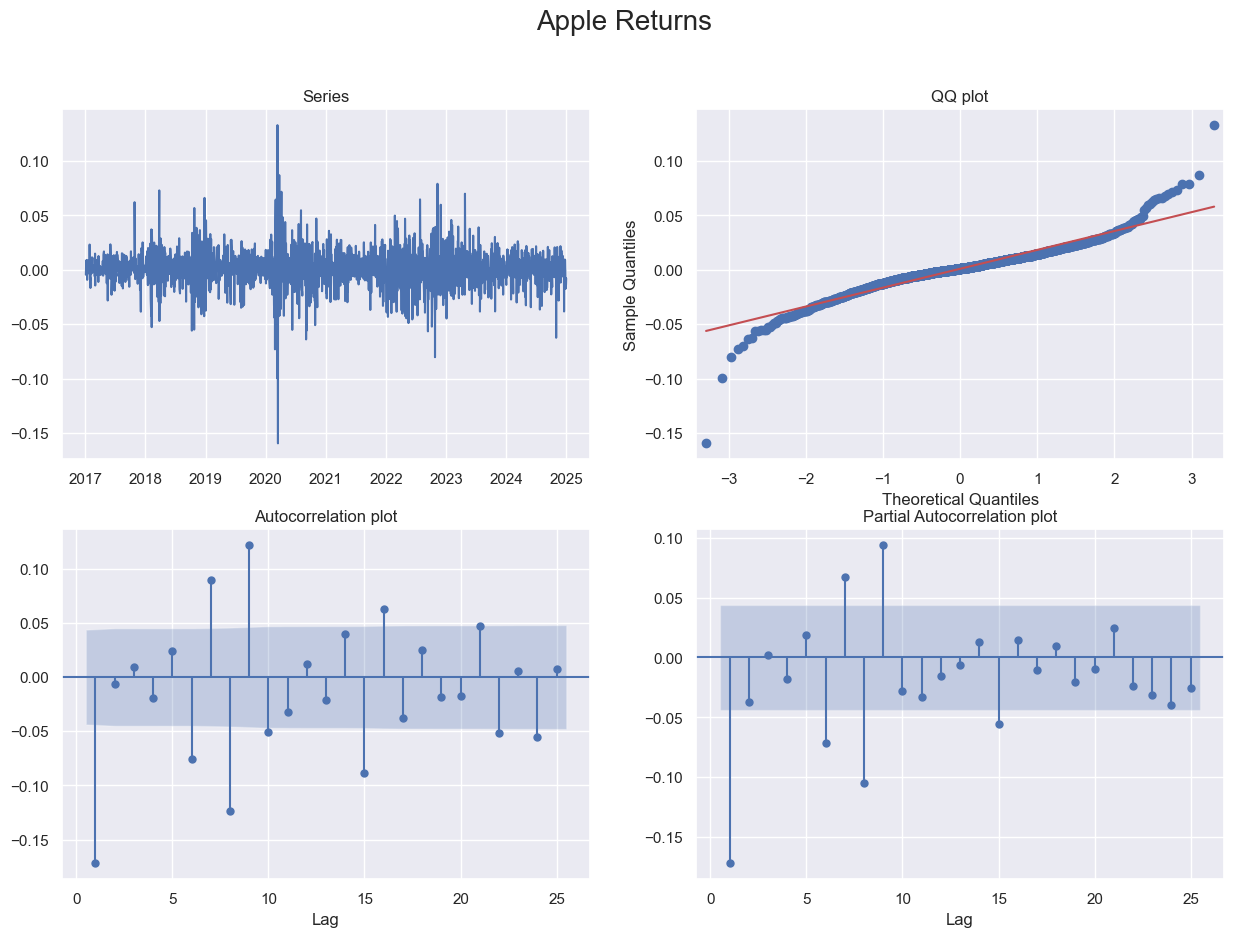

In [648]:
ts_plot(AAPL['LOG RETS'] / 100, 25, 'Apple Returns')

Text(0.5, 1.0, 'AAPL Monthly Realised Volatility')

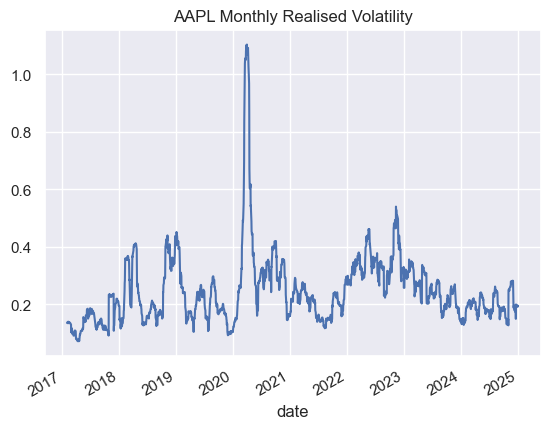

In [660]:
#Realised Vol Plot
AAPL_realised_vol = realised_volatility(AAPL['LOG RETS'] / 100, 21, 252)
AAPL_realised_vol.plot()
plt.title('AAPL Monthly Realised Volatility')

## GARCH 

    - Returns should be integer % values (required by arch library). 
    - Realised volatility : use formula based estimators (Garman Klass) or actual realized vol

In [607]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

In [662]:
#Split Date at June 2023
split_date = dt.datetime(2023, 6, 1)
AAPL['LOG RETS']

date
2017-01-04   -0.448431
2017-01-05    0.000000
2017-01-06    0.863039
2017-01-09   -0.318776
2017-01-10   -0.031934
                ...   
2024-12-24    0.933024
2024-12-26   -0.278082
2024-12-27   -1.745299
2024-12-30   -1.332794
2024-12-31   -0.786929
Name: LOG RETS, Length: 2011, dtype: float64

In [663]:
AAPL_GARCH = arch_model(AAPL['LOG RETS'] / 100,
                        p = 1 , q = 1,
                        mean = 'AR',
                        lags = 1,
                        vol = 'GARCH',
                        dist = 'normal')

AAPL_GARCH_Result = AAPL_GARCH.fit(update_freq=0, last_obs = split_date, disp='on')

In [668]:
AAPL_GARCH_Result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:               LOG RETS   R-squared:                       0.031
Mean Model:                        AR   Adj. R-squared:                  0.031
Vol Model:                      GARCH   Log-Likelihood:                4422.92
Distribution:                  Normal   AIC:                          -8835.84
Method:            Maximum Likelihood   BIC:                          -8808.91
                                        No. Observations:                 1611
Date:                Wed, May 14 2025   Df Residuals:                     1609
Time:                        17:34:27   Df Model:                            2
                                  Mean Model                                 
=============================================================================
                  coef    std err          t      P>|t|      95.0% Conf. Int.
-----------------------------------------------------------------------------
Const       1.6295e-03  1.339e-04     12.173  4.341e-34 [1.367e-03,1.892e-03]
LOG RETS[1]    -0.1398  2.867e-02     -4.877  1.075e-06  [ -0.196,-8.364e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      6.9709e-06  3.163e-11  2.204e+05      0.000 [6.971e-06,6.971e-06]
alpha[1]       0.1004  2.665e-02      3.766  1.657e-04   [4.814e-02,  0.153]
beta[1]        0.8796  2.328e-02     37.785      0.000     [  0.834,  0.925]
============================================================================

Covariance estimator: robust
"""

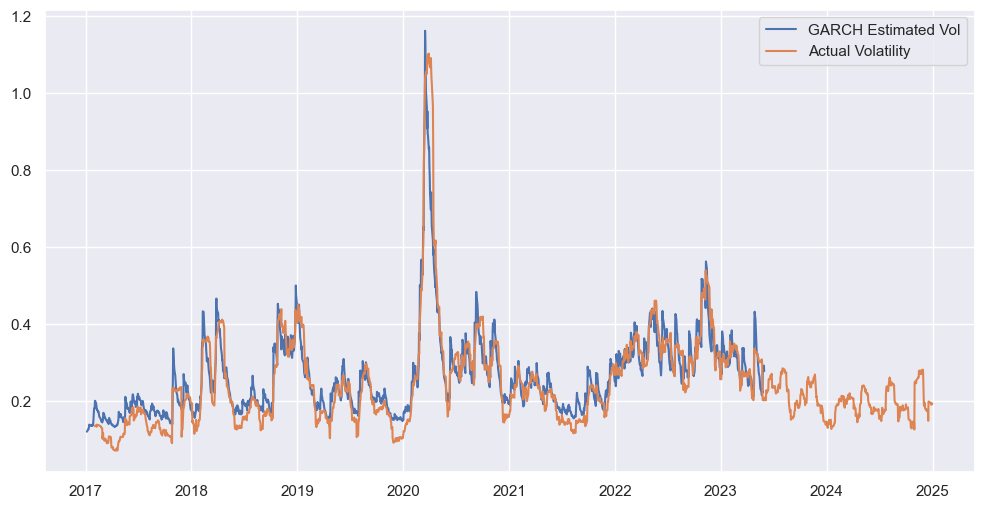

In [684]:
# Must make sure the volatility units are the same - the RV function calculates annualised
# ARCH model gives what whatever format we fed it via the DF
Annualised_Conditional_Vols_GARCH = AAPL_GARCH_Result.conditional_volatility.dropna() * 16

plt.figure(figsize=(12,6))
plt.plot(Annualised_Conditional_Vols_GARCH, label = 'GARCH Estimated Vol')
plt.plot(AAPL_realised_vol, label = 'Actual Volatility')
plt.legend()

### Model Validation

Check the standardised SQUARED residuals to see if there is any structure left we haven't taken in via our model.

Note
    - Fat tails in QQ Plot => U shaped => asymmetric suggests a different distribution is needed to model the residuals
    - But GARCH model has removed serial correlation in the squared residuals relatively successfully from the plot
    - But must use Ljung Box statistics for squared and normal standardised residuals

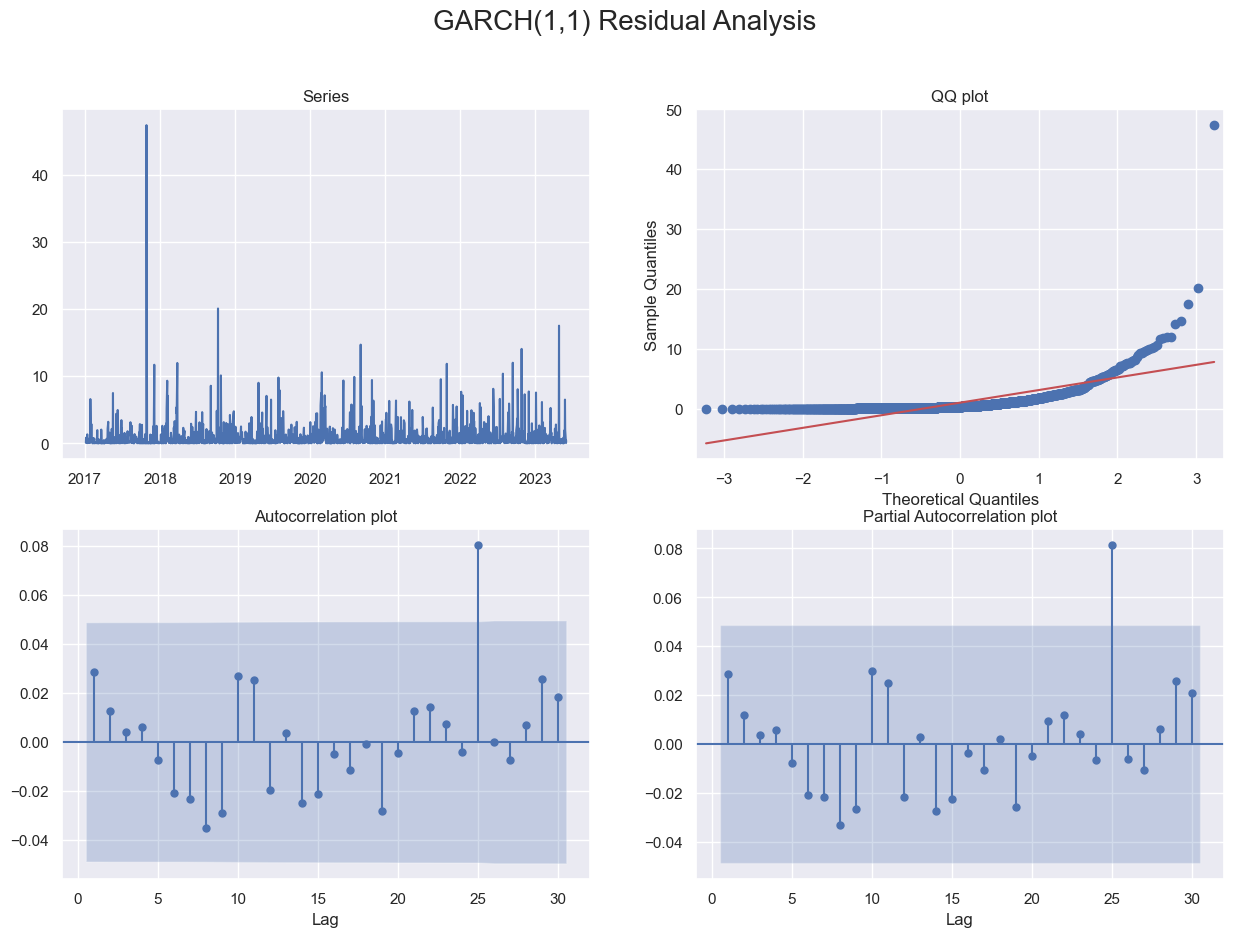

In [687]:
ts_plot(AAPL_GARCH_Result.std_resid.dropna() ** 2, max_lags = 30,
        title='GARCH(1,1) Residual Analysis')

In [693]:
residual_ljungbox = sm.stats.acorr_ljungbox(AAPL_GARCH_Result.std_resid.dropna(), lags=None)
squared_residual_ljungbox = sm.stats.acorr_ljungbox(AAPL_GARCH_Result.std_resid.dropna() ** 2, lags = None)

In [694]:
residual_ljungbox

,lb_stat,lb_pvalue
1,4.227306,0.039779
2,8.633831,0.013341
3,8.748795,0.032824
4,8.957677,0.062166
5,9.856483,0.079405
6,10.764161,0.095945
7,12.040605,0.099231
8,15.965014,0.042884
9,16.257720,0.061691
10,16.291690,0.091581


In [695]:
squared_residual_ljungbox

,lb_stat,lb_pvalue
1,1.310630,0.252281
2,1.569395,0.456258
3,1.598040,0.659834
4,1.658195,0.798297
5,1.746879,0.882942
6,2.461727,0.872726
7,3.331634,0.852724
8,5.321391,0.722738
9,6.694600,0.668882
10,7.870227,0.641511


The ljung box test exclude now autocorrelation from the standardized residuals, however, when looking at the test statistic for the squared of the standardized residuals, there is still persistence of some kind of correlation after lag 2, since all the remaining lags reject the null hypotheses of absence of autocorrelation. 

This means that there are some remaining patterns or structures in the volatility that are not adequately captured by the model. 

## Changing Distribution to Specify Residuals

### T Student Distribution

<Axes: xlabel='date'>

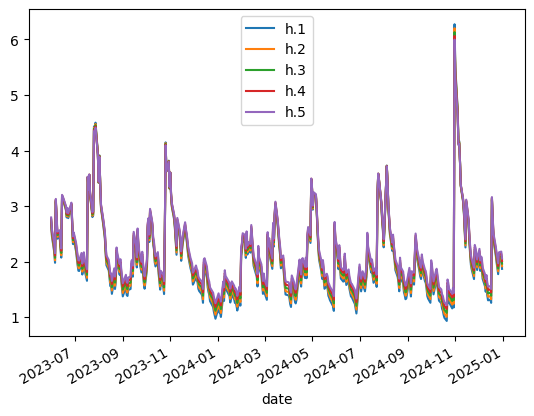

In [501]:
AAPL_Forecast.variance[split_date:].plot()

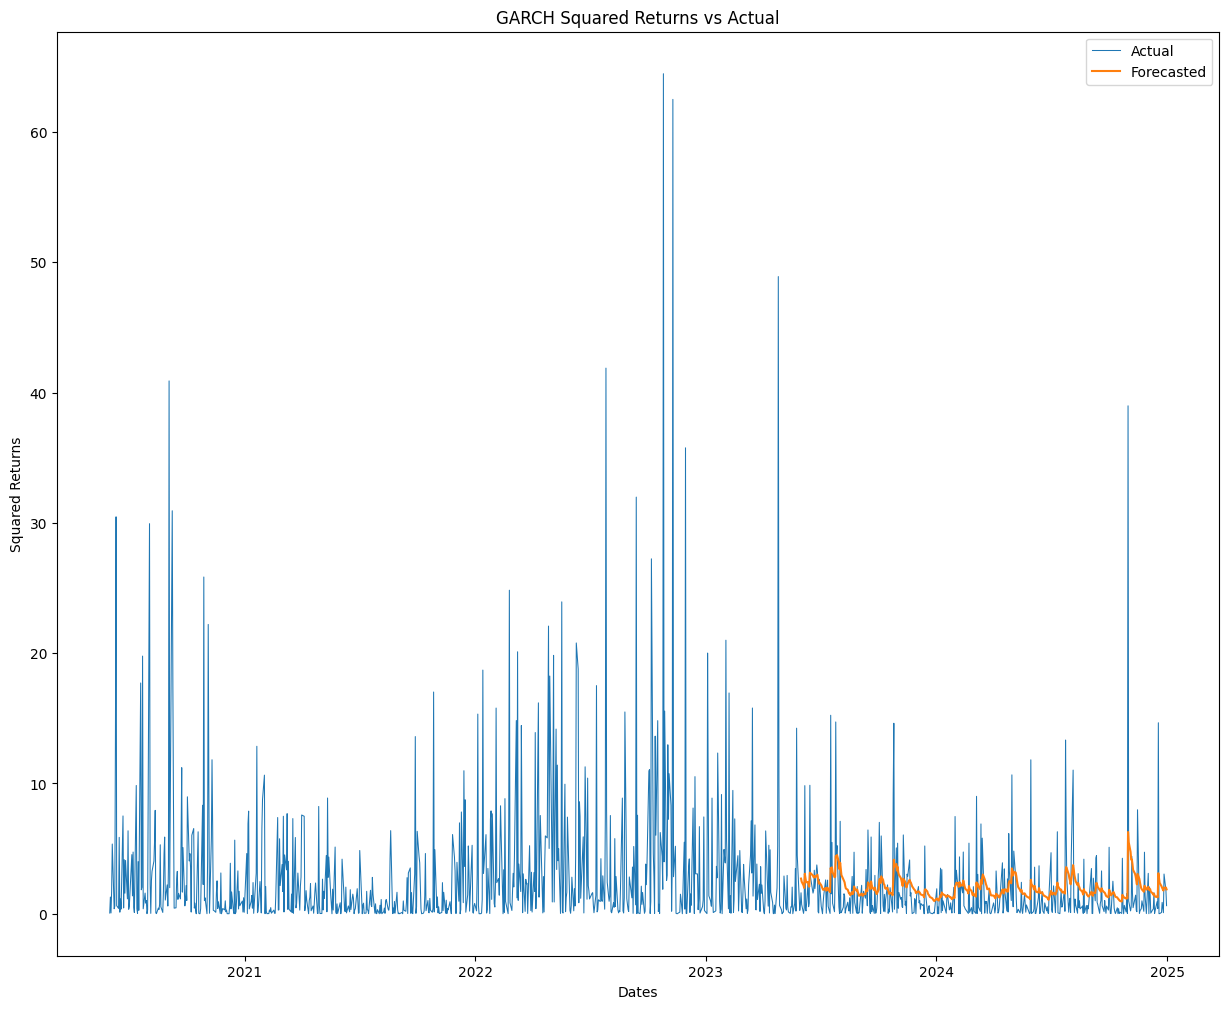

In [547]:
fig, ax = plt.subplots(figsize=(15, 12))
ax.plot(AAPL.loc['2020-06-01':, 'SQUARED RETS'], linewidth = .75, label = 'Actual')
ax.plot(AAPL_Forecast.variance['2020-06-01':].iloc[:, 0], label = 'Forecasted')
plt.title('GARCH Squared Returns vs Actual')
plt.xlabel('Dates')
plt.ylabel('Squared Returns')
plt.legend()

## Rolling GARCH

In [506]:
AAPL_index = AAPL.index
start_loc = 0
end_loc = np.where(AAPL_index >= '2024-12-31')[0].min() - 250
AAPL_forecast_variances = {}
AAPL_GARCH_Rolling = arch_model(AAPL['LOG RETS'], p = 1, q = 1, vol = 'GARCH')

In [528]:
AAPL_index = AAPL.index
start_loc = 0
end_loc = np.where(AAPL_index >= '2024-12-31')[0].min() - 250
AAPL_forecast_variances = {}
AAPL_GARCH_Rolling = arch_model(AAPL['LOG RETS'], p = 1, q = 1, vol = 'GARCH')

for i in range(250):
    results = AAPL_GARCH_Rolling.fit(first_obs = i, last_obs = end_loc + i, disp = 'off')
    temp = results.forecast(horizon = 1).variance
    fcast = temp.iloc[0]
    AAPL_forecast_variances[fcast.name] = fcast
    if fcast.name == AAPL.index[-1]:
        print(i)
        break


In [539]:
AAPL_forecast_variances_df = pd.DataFrame(AAPL_forecast_variances.values(), index = AAPL_forecast_variances.keys())

Text(0.5, 1.0, 'Rolling Predictions vs Actual')

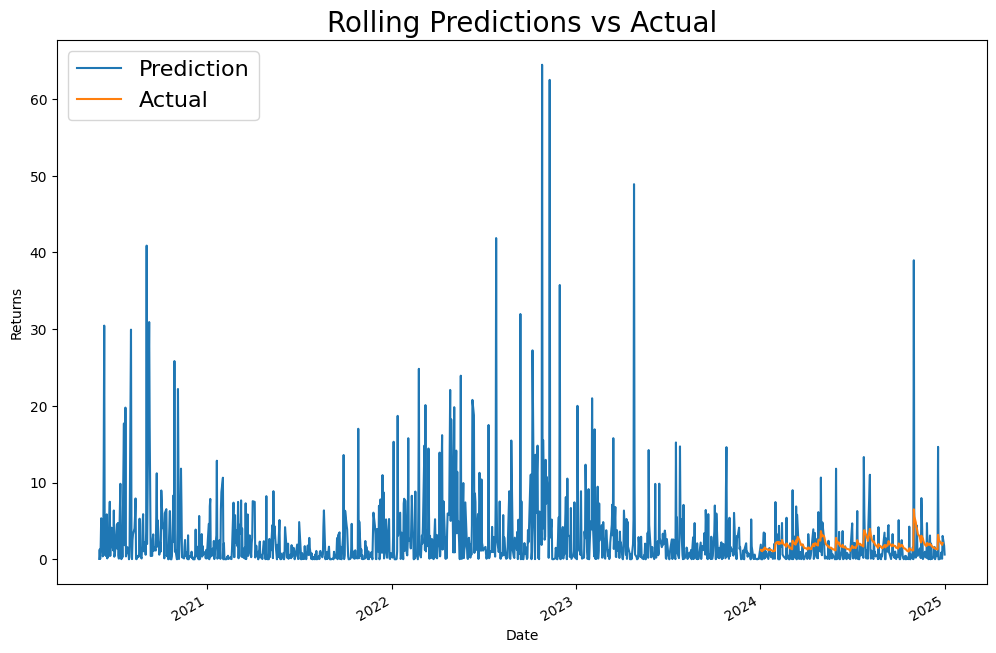

In [554]:
#Plot Predictions
fig, ax = plt.subplots(figsize = (12,8))
plt.xlabel('Date')
plt.ylabel('Returns')
plt.gcf().autofmt_xdate()
plt.plot(AAPL['SQUARED RETS'].loc['2020-06-01':], label = 'Actual Squared Returns')
plt.plot(AAPL_forecast_variances_df.loc['2020-06-01':], label = 'Predicted Squared Returns')
plt.legend(['Prediction', 'Actual'], loc = 'upper left', fontsize = 16)
plt.title('Rolling Predictions vs Actual', fontsize = 20)

## Tests for Autocorrelation Squared Returns

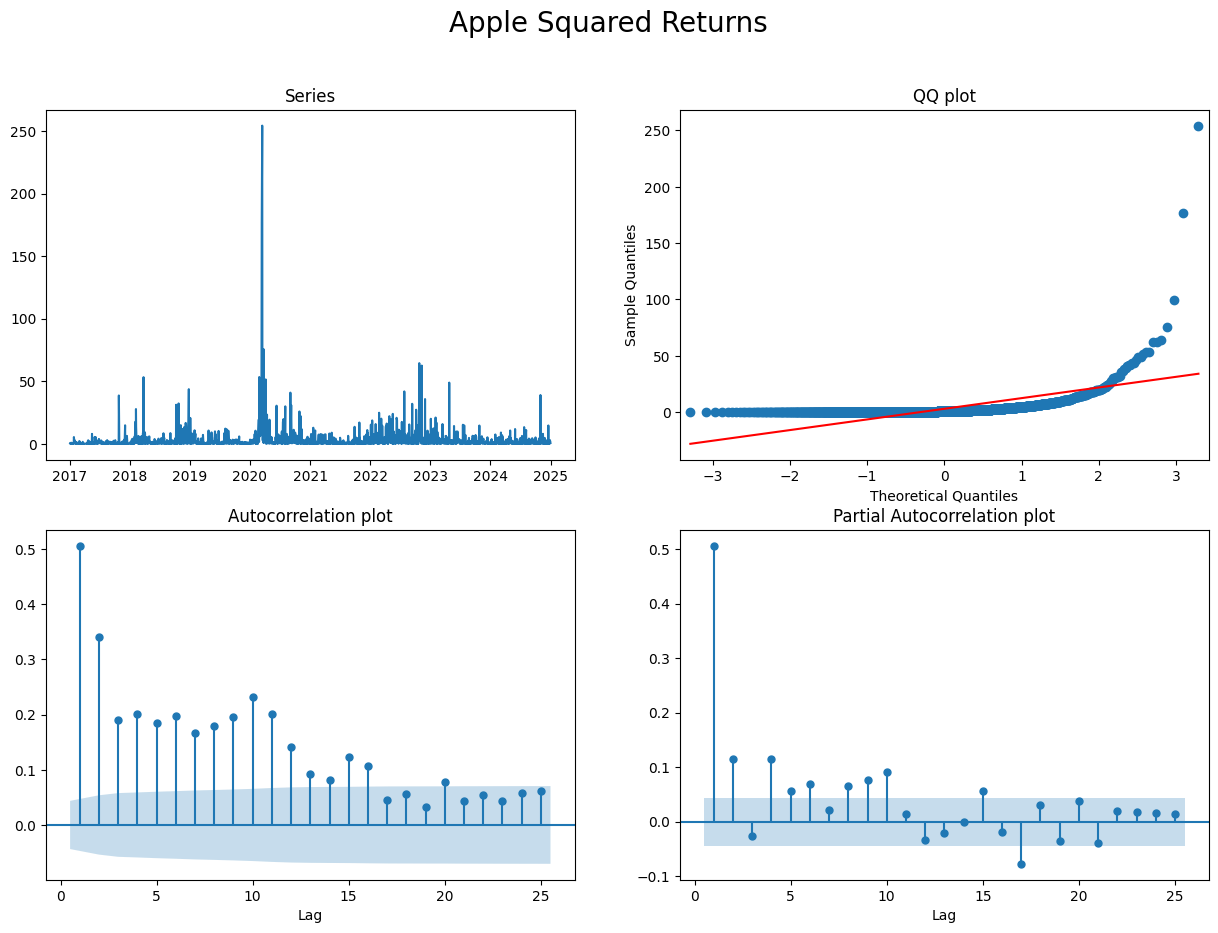

In [557]:
#Visualisation shows autocorrelation structure exists in squared returns
ts_plot(AAPL['SQUARED RETS'], 25, 'Apple Squared Returns')

#### Ljung-Box test 

Another way to check the presence of autocorrelation in the data is using the Ljung Box test statistic, for which:

- $H_0$ : The data are independently distributed; No Autocorrelation
- $H_1$ : The data are not independently distributed; they exhibit serial correlation.

In [568]:
#Use Ljung Box Test
LjungBox = sm.stats.acorr_ljungbox(AAPL['SQUARED RETS'], lags=None, auto_lag=True)
LjungBox.head()

,lb_stat,lb_pvalue
1,516.120162,2.955684e-114
2,750.645788,9.984773e-164
3,824.131736,2.526572e-178
4,905.119776,1.295307e-194
5,973.524041,3.240537e-208


In [574]:
print('Number of Violations (when p-value is above 5%) :', (LjungBox['lb_pvalue'] > 0.05).sum())

Number of Violations (when p-value is above 5%) : 0


#### Analysis of Apple's Returns

Now that we can conclude there does exist autocorrelation within squared returns, we look into the returns distribution

In [591]:
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

returns = AAPL['LOG RETS'] / 100

In [588]:
sns.set(style="darkgrid", color_codes=True)

Text(0.5, 1.0, '2nd anomaly: higher spike of AAPL returns distribution')

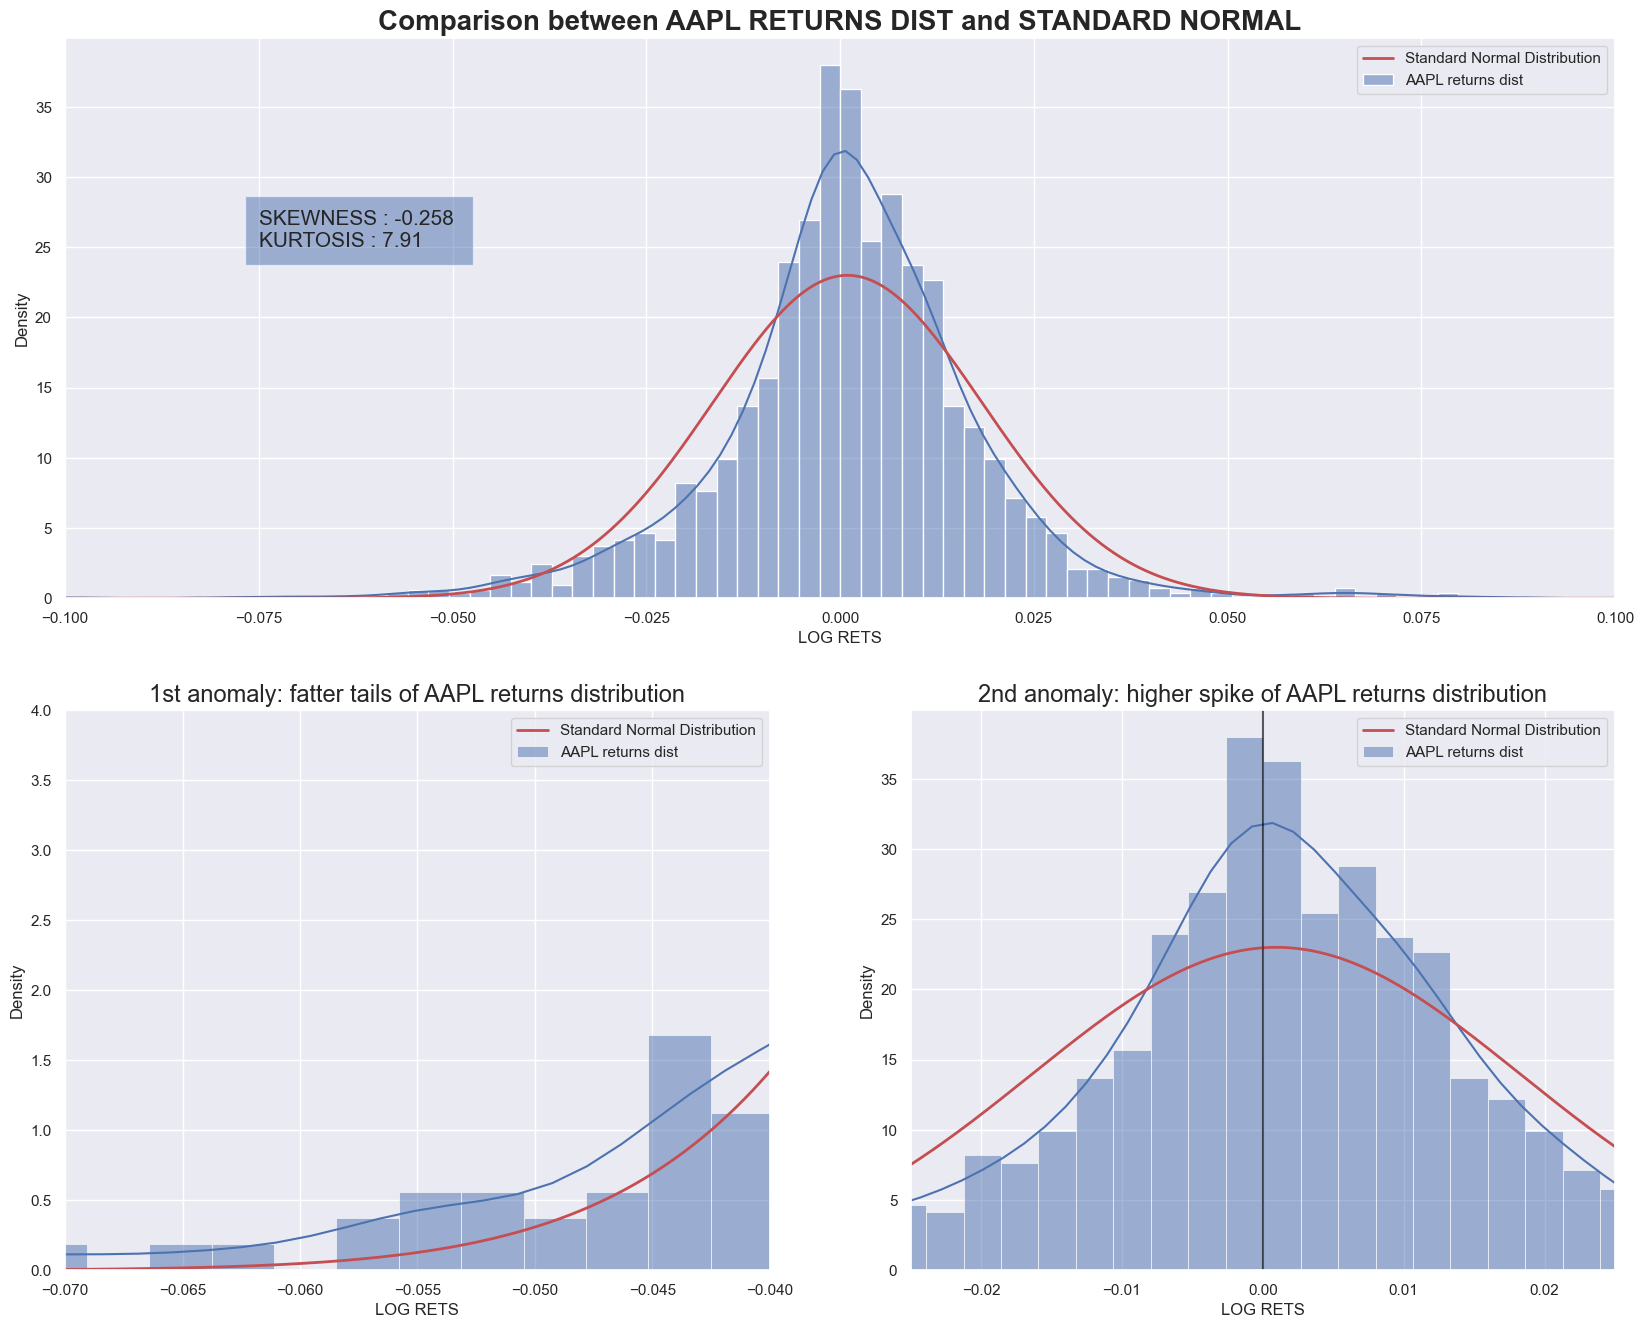

In [593]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

gs = fig.add_gridspec(2, 2)
ax = fig.add_subplot(gs[0, :]) # add one subplot in the two grids of the first row
axs[0, 0].set_yticks([]) 
axs[0, 0].set_xticks([])
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])


sns.histplot(returns, stat='density', kde=True, label='AAPL returns dist')
ax.set_xlim([-0.10, 0.10])
x = np.linspace(-0.1, 0.1, 1000)
p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
ax.plot(x, p, 'r', linewidth=2, label='Standard Normal Distribution')
ax.legend()
ax.set_title('Comparison between AAPL RETURNS DIST and STANDARD NORMAL', fontsize=20, fontweight='bold')
ax.text(-0.075, 25, f'SKEWNESS : {returns.skew():.3} \nKURTOSIS : {returns.kurtosis():.3}', style='normal',
        bbox={'alpha': 0.5, 'pad': 10}, fontsize=15)

# Lower-left plot (focus on left fat tail)
sns.histplot(returns, stat='density', kde=True, ax = axs[1, 0], label='AAPL returns dist')
axs[1, 0].set_xlim([-0.07, -0.04])
axs[1, 0].set_ylim([0, 4])
x = np.linspace(-0.07, -0.04, 10000)
p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
axs[1, 0].plot(x, p, 'r', linewidth=2, label='Standard Normal Distribution')
axs[1, 0].legend()
axs[1, 0].set_title('1st anomaly: fatter tails of AAPL returns distribution', fontsize=17)


# Lower-right plot (focus on the central leptokurticity)
sns.histplot(returns, stat='density', kde=True, ax = axs[1, 1], label='AAPL returns dist')
axs[1, 1].set_xlim([-0.025, +0.025])
axs[1, 1].axvline(0, c='black', alpha=0.4)
x = np.linspace(-0.025, +0.025, 10000)
p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
axs[1, 1].plot(x, p, 'r', linewidth=2, label='Standard Normal Distribution')
axs[1, 1].axvline(0, c='black', alpha=0.4)
axs[1, 1].legend()
axs[1, 1].set_title('2nd anomaly: higher spike of AAPL returns distribution', fontsize=17)



## Basic Regime Detection